## Churn Analysis and Customer Intelligence

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### 1. Import database / data

In [2]:
# Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database
conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    # Read table into dataframe
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    # Create dynamic dataframe name
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
# PRAGMA is a special command in SQLite used to:
# inspect db information, control db settings, retrieve metadata about tables

### 2. Data Cleaning


In [5]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
# a. rename col - name to customer_name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace=True)

In [8]:
# b. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)

df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [9]:
# c. change data type - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [10]:
# d. data standardization - gender

# df_db_customer['gender'].unique()

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})

In [11]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [12]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(
    subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(
    df_db_customer['state'].map(state_country_mapping))

In [13]:
df_db_customer[df_db_customer['country'].isna()] # no null value in country col

,customerid,customer_name,country,state,gender,dob


In [14]:
df_db_subscription.head() # subcription table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [15]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [16]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [17]:
display(df_db_support)

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [18]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [19]:
# drop column

df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [20]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


### 3. feature Engineering and Data Analysis

In [21]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [22]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after

df = (df_db_subscription
      .merge(df_db_customer, on='customerid', how='left')
      .merge(df_db_support, on='customerid',  how='left'))

In [23]:
df_db_subscription.shape

(21, 12)

In [24]:
df.shape

(23, 20)

In [25]:
df_db_customer['customerid'].nunique()

21

In [26]:
df_db_subscription['customerid'].nunique()

21

In [27]:
df_db_support['customerid'].nunique()

7

In [28]:
df_db_support['customerid'].size

9

In [29]:
df_db_support['complain_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')


In [30]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complain_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [31]:
# Fix: keep the deduplicated support table (most recent complaint per customer)
# Previously this line's output wasn't saved to a variable, so the merge below
# was still using the RAW duplicated df_db_support -> caused row fan-out (21 -> 23 rows)
df_db_support_dedup = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')
df_db_support_dedup

,customerid,complaint_date,escalations,csat_score,complain_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [32]:
# merge df - now using df_db_support_dedup (1 row per customer) instead of raw df_db_support

df = (df_db_subscription
      .merge(df_db_customer, on='customerid', how='left')
      .merge(df_db_support_dedup, on='customerid',  how='left'))

In [33]:
df.shape

(21, 21)

In [34]:
# Churn Analysis
df.to_csv('exported_churn_data.csv', index = False)


In [35]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='object')

In [36]:
# 1. Churn rate 

churn_rate = df['churn_flag'].mean()*100
print("churn_rate = ", round(churn_rate, 2), "%") 

churn_rate =  28.57 %


In [37]:
# 2. Retention rate

retention_rate = 100 - churn_rate
print("retention_rate = ", round(retention_rate, 2),  "%")

retention_rate =  71.43 %


In [38]:
# 3. Churn by plan type

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_%'))
print(churn_by_plan)

  plan_type  churn_rate_%
0     Basic         60.00
1   Premium         14.29
2  Standard         22.22


In [39]:
# 4 a. Churn by state + sum(revenue) & count of users
# Group data by state
# Calculate churn rate (%), total revenue, and total number of users

churn_by_state = (
    df.groupby('state')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          total_revenue=('monthly_charges', 'sum'),
          total_users=('customerid', 'nunique')
      )
      .reset_index()
)

print(churn_by_state)


           state  churn_rate_pct  total_revenue  total_users
0          Delhi           25.00          52.96            4
1      Karnataka          100.00          20.98            2
2      Kathmandu            0.00          20.98            2
3    Maharashtra            0.00          50.97            3
4      Meghalaya           66.67          42.97            3
5       Nagaland            0.00          22.99            1
6      Rajasthan            0.00          36.98            2
7      Telangana           50.00          30.98            2
8  Uttar Pradesh            0.00         115.98            2


In [40]:
# 4 b. Churn by subscription type + sum(revenue) & count of users
# Group data by subscription type
# Calculate churn rate (%), total revenue, and total number of users

churn_by_subscription = (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          total_revenue=('monthly_charges', 'sum'),
          total_users=('customerid', 'nunique')
      )
      .reset_index()
)

print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  total_users
0           Organic            0.00         145.91            9
1              Paid           16.67         174.94            6
2          Refferal           83.33          74.94            6


In [41]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [42]:
# Avg Customer tenure
# count of days users has used our servic : cancellation date else current date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    
        df['cancellation_date'].notna(),
        
        (df['cancellation_date'] - df['subscription_start_date']).dt.days,
        
        (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (days) = ", round(avg_tenure, 0))

Avg Tenure (days) =  1490.0


In [43]:
# 7. Revenue at risk - revenue lost from churned users

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at risk (Rs. 'K') = ", revenue_at_risk)

Revenue at risk (Rs. 'K') =  73.94


In [44]:
# 8. Escalation rate 

escalation_rate = (df['escalations'] == 'Y').mean()*100
print("escalation_rate = ", round(escalation_rate, 2), "%")

escalation_rate =  19.05 %


In [45]:
# 9. Avg Complaint per user

avg_complaints = df['complain_count'].sum() / df['customerid'].nunique()
print("Avg complaints per user = ", round(avg_complaints, 2))

Avg complaints per user =  0.43


In [46]:
# 10. Correlation Escalation vs churn 

corr_df = df[['escalations', 'churn_flag']].dropna().copy()
corr_df['escalations'] = np.where(corr_df['escalations'] == 'Y', 1, 0)  # encode locally, don't mutate df

# correlation
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

print("Correlation between escalation vs churn is = ", round(correlation, 2))

Correlation between escalation vs churn is =  0.47


In [47]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1941.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0


In [48]:
# 11. Create a column using existing column - Churn risk

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

### 4. Visualization using Matplotlib

In [49]:
df_visual = df.copy()

In [50]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

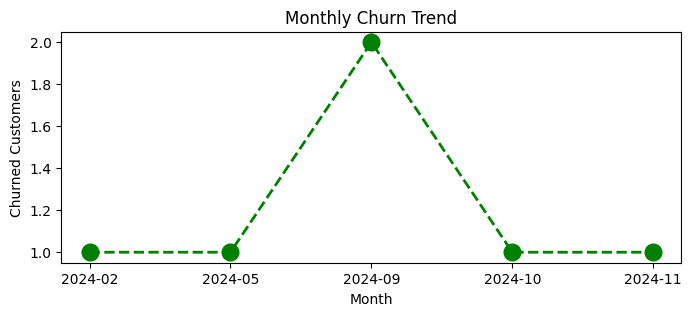

In [51]:
# 4.1 Monthly Churn trend (TIme series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1 ].groupby('cancellation_month').size()

plt.figure(figsize = (8, 3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color = 'green', marker = 'o', linestyle = 'dashed', linewidth = 2, markersize =12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

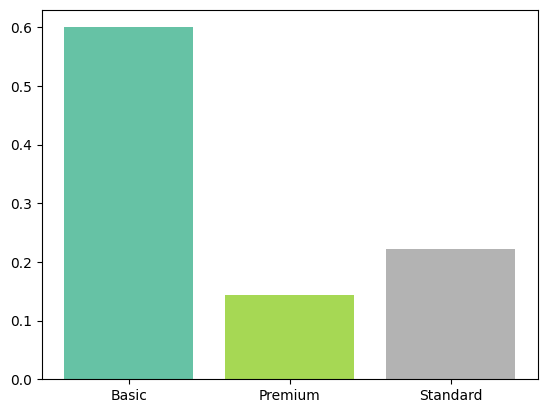

In [52]:
# 4.2 Churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.Figure(figsize=(7, 4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

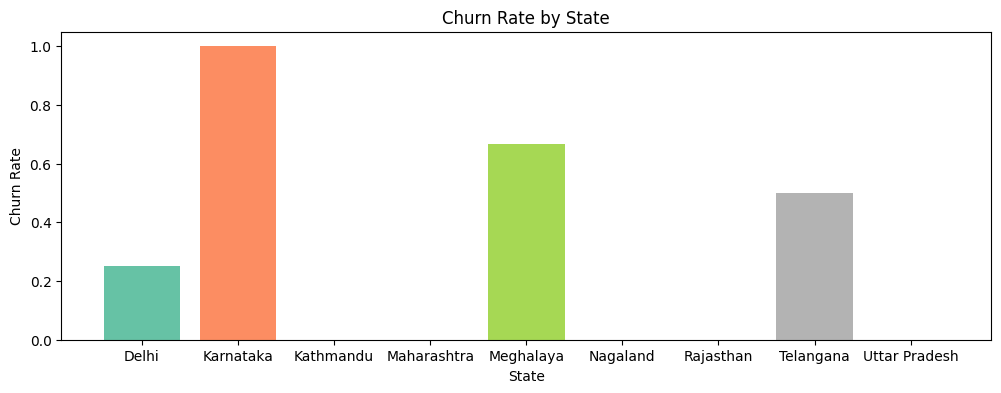

In [53]:
# 4.3 Churn by States

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12, 4))

plt.bar(churn_plan.index, churn_plan.values, color=colors)

plt.title("Churn Rate by State")
plt.xlabel("State")
plt.ylabel("Churn Rate")

plt.show()

### 5. Visualization using Seaborn

In [54]:
# encoding - convert str to numeric so that we can find corr b/w features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [55]:
# Incorrect method of encoding - as numbers are not assigned based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'churn_risk', 'escalations']].copy()  # removed .head() - was silently limiting corr to 5 rows

categorical_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

df_encoded['escalations'] = np.where(df_encoded['escalations'] == 'Y', 1, 0)  # was missing, relied on stale kernel state before

In [56]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

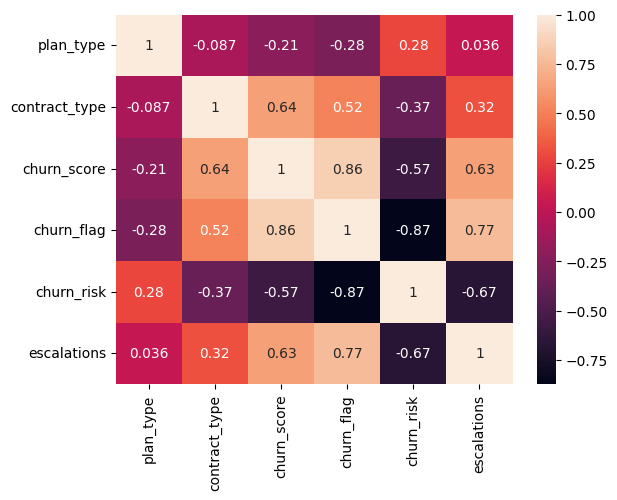

In [57]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [58]:
df_visual['escalations'] = np.where(
    df_visual['escalations'] == 'Y',
    1,
    0
)

In [59]:
# Correct method of encoding - based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score',
                        'churn_flag', 'churn_risk', 'escalations']].copy()

order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

# escalations is already 0/1 (converted in the cell above) - do NOT re-run the
# 'Y' string comparison here, it's already numeric and would zero everything out

In [60]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [61]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

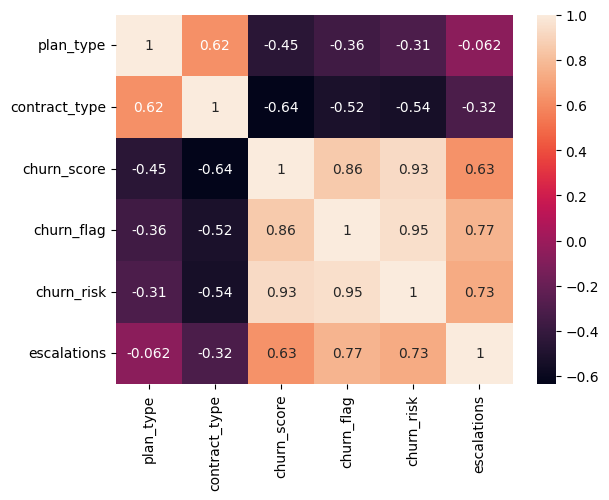

In [62]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

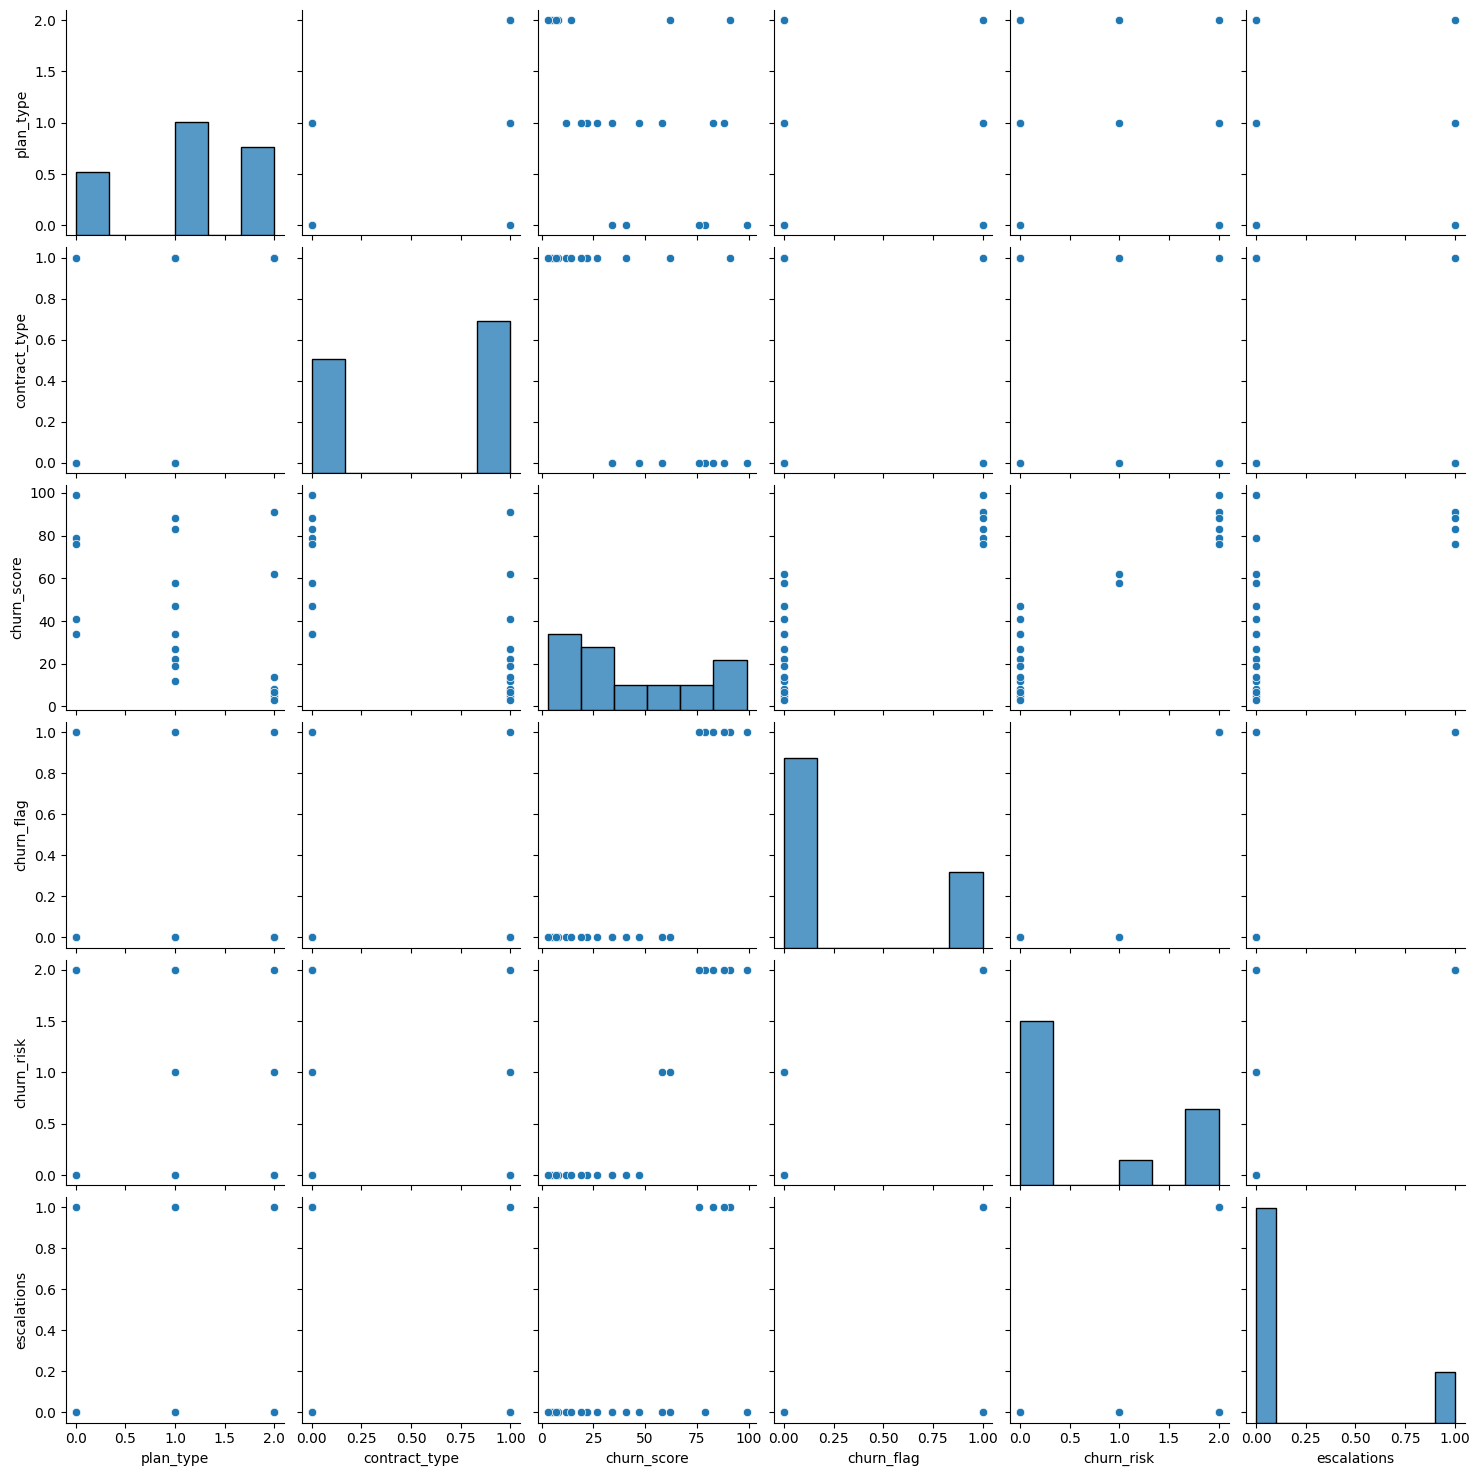

In [63]:
# pairplot - relationship in a dataset 

sns.pairplot(df_encoded)

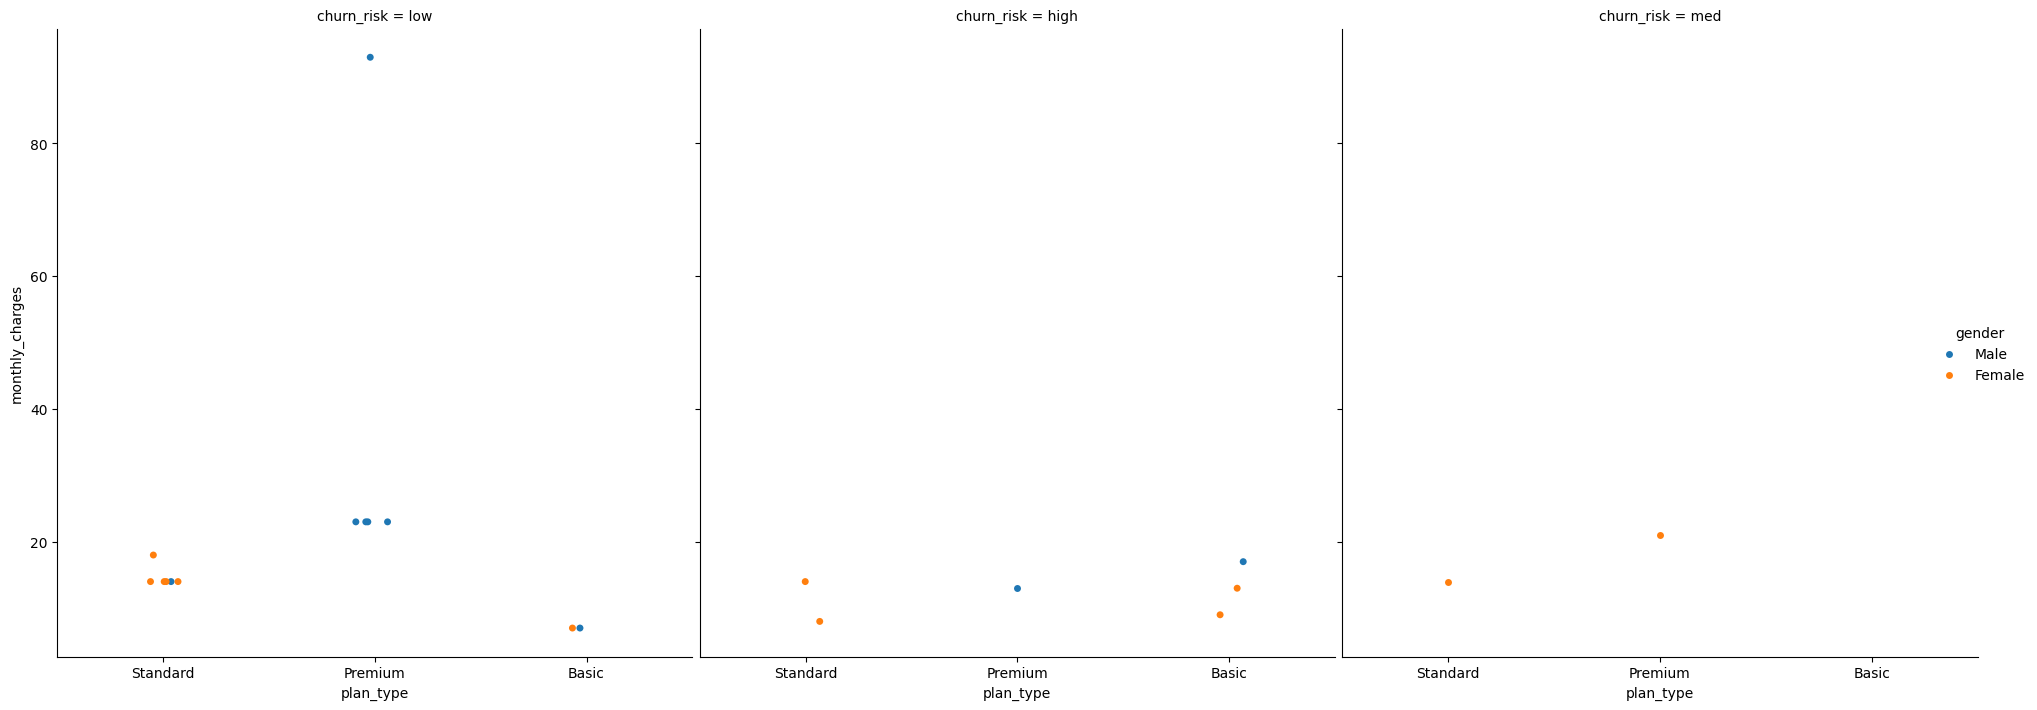

In [64]:
# catplot/facegrid plot - multi - dim comparison 

g = sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk',
    height=9,
    aspect=2
)

g.fig.set_size_inches(20, 7)
plt.show()

In [65]:
# Pivot table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [67]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc={
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag': 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [68]:
# working with SQL in Python (pandas)

In [69]:
# create db in sql

conn = sqlite3.connect('test_database.sqlite')

# table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save

conn.commit()

In [ ]:
# insert data

cursor = conn.cursor()

# write sql query to insert records in sql table
cursor.execute("""
INSERT INTO users (first_name, country, budget)
        VALUES
            ('Krishna', 'India', 50000),
            ('Rahul', 'India', 35000),
            ('John', 'USA', 80000),
            ('Emma', 'UK', 65000),
            ('Akash', 'India', 42000);
        """)

conn.commit()

# commit and save
conn.commit()
print("Data Inserted Successfully")

Data Inserted Successfully


In [75]:
# check inserted data in table

conn = sqlite3.connect('test_database.sqlite')

query = """ SELECT * FROM users """

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Krishna,India,50000
1,Rahul,India,35000
2,John,USA,80000
3,Emma,UK,65000
4,Akash,India,42000


In [76]:
# aggregation 

query = """
        SELECT country, sum(budget) as total_budget
        FROM users
        GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,India,127000
1,UK,65000
2,USA,80000


In [ ]:
# always close the conn with db once the task is over
conn.close()